# Import libraries

In [1]:
!pip -q install seqeval torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

import random
import numpy as np
import pandas as pd
import os
from pathlib import Path
from functools import partial

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
	AutoModelForSequenceClassification,
	PreTrainedModel,
	PretrainedConfig,
    Trainer,
    TrainingArguments,
	DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    PreTrainedTokenizerFast,
	EarlyStoppingCallback,
	pipeline
)
from transformers.modeling_outputs import (
	TokenClassifierOutput,
	SequenceClassifierOutput
)


from tokenizers import Tokenizer, models, trainers, pre_tokenizers

from datasets import load_dataset

# ABTE (sequence labeling)
from seqeval.metrics import (
    classification_report as seq_cls_report,
    f1_score as seq_f1,
    precision_score as seq_precision,
    recall_score as seq_recall,
    accuracy_score as seq_acc,
)

# ABSC (classification)
from sklearn.metrics import (
    classification_report as skl_cls_report,
    precision_recall_fscore_support,
    accuracy_score as skl_acc,
)

In [3]:
IGNORE_INDEX = -100
SEED = 42

In [4]:
def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)

	torch.manual_seed(seed)

	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass

set_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Download & EDA dataset

In [5]:
ds = load_dataset("thainq107/abte-restaurants")

README.md:   0%|          | 0.00/454 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/183k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/61.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3602 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1119 [00:00<?, ? examples/s]

In [6]:
ds

DatasetDict({
    train: Dataset({
        features: ['Tokens', 'Tags', 'Polarities'],
        num_rows: 3602
    })
    test: Dataset({
        features: ['Tokens', 'Tags', 'Polarities'],
        num_rows: 1119
    })
})

In [7]:
ds['train'][0]

{'Tokens': ['But', 'the', 'staff', 'was', 'so', 'horrible', 'to', 'us', '.'],
 'Tags': ['0', '0', '1', '0', '0', '0', '0', '0', '0'],
 'Polarities': ['-1', '-1', '0', '-1', '-1', '-1', '-1', '-1', '-1']}

In [ ]:
def get_length(examples):
    return {
        "length": [len(ids) for ids in examples["Tokens"]]
    }

length_dataset = ds.map(
    get_length,
    batched=True,
    num_proc=2,
    remove_columns=['Tokens', 'Tags', 'Polarities']
)

Map (num_proc=2):   0%|          | 0/3602 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1119 [00:00<?, ? examples/s]

--- Statistics for train ---
Mean: 20.04 | Max: 79 | p95: 40 | p99: 50

--- Statistics for test ---
Mean: 19.00 | Max: 70 | p95: 38 | p99: 50



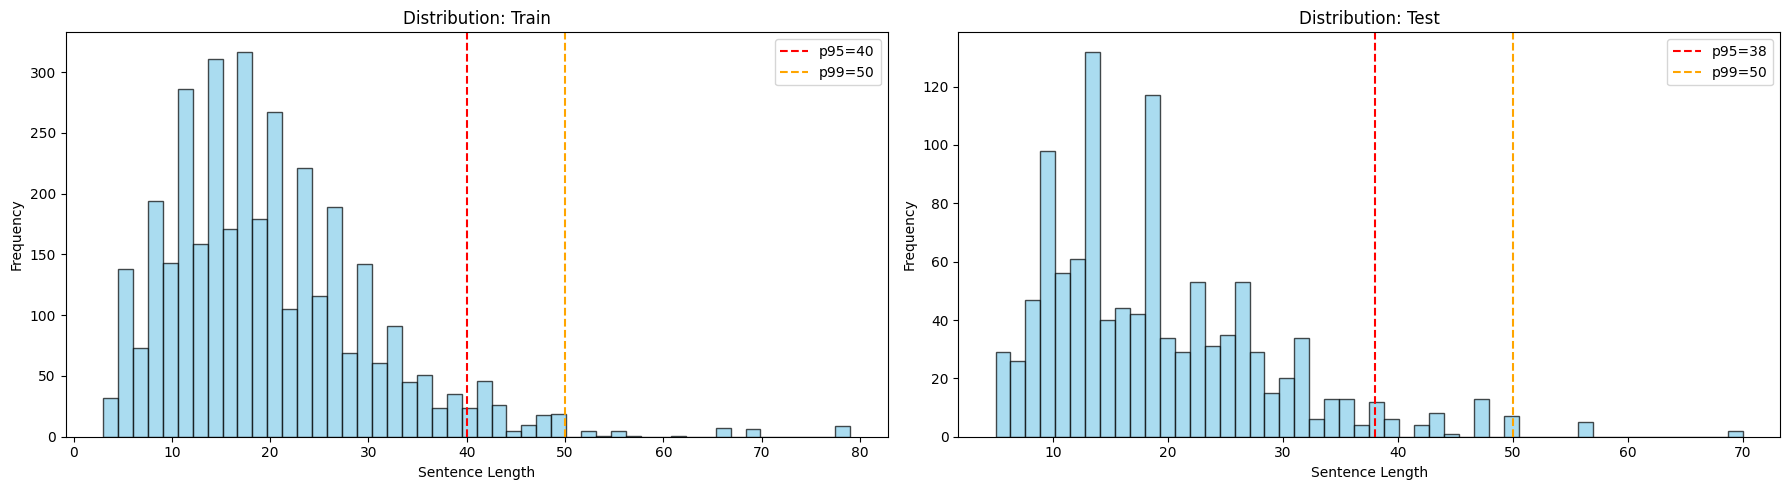

In [ ]:
dataset_stats = {}
splits = ["train", "test"]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for i, split in enumerate(splits):
    # 1. Trích xuất độ dài
    lengths = np.array(length_dataset[split]["length"])

    # 2. Tính toán các chỉ số
    p95 = int(np.percentile(lengths, 95))
    p99 = int(np.percentile(lengths, 99))
    max_val = int(lengths.max())
    mean_val = lengths.mean()

    # 3. Lưu vào dictionary
    dataset_stats[split] = {
        "p95": p95,
        "p99": p99,
        "max_len": max_val,
        "mean": mean_val
    }

    # 4. In thông tin ra màn hình
    print(f"--- Statistics for {split} ---")
    print(f"Mean: {mean_val:.2f} | Max: {max_val} | p95: {p95} | p99: {p99}\n")

    # 5. Vẽ biểu đồ histogram lên subplot tương ứng
    axes[i].hist(lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(p95, color='red', linestyle='--', label=f'p95={p95}')
    axes[i].axvline(p99, color='orange', linestyle='--', label=f'p99={p99}')

    axes[i].set_title(f'Distribution: {split.capitalize()}')
    axes[i].set_xlabel('Sentence Length')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 2. Utils

In [8]:
abte_id2label = {
    0: "O",
    1: "B-Term",
    2: "I-Term"
}

abte_label2id = {
    "O": 0,
    "B-Term": 1,
    "I-Term": 2
}

def tokenize_and_align_labels(tokenizer, examples):
    tokenized = tokenizer(
        examples["Tokens"],
        is_split_into_words=True,
        padding=False,
        truncation=True
    )

    labels = []

    for i, tags in enumerate(examples["Tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        previous_word_id = None

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(IGNORE_INDEX)

            elif word_id != previous_word_id:
                label_ids.append(int(tags[word_id]))

            else:
                label_ids.append(IGNORE_INDEX)

            previous_word_id = word_id

        labels.append(label_ids)

    tokenized["labels"] = labels
    return tokenized

def abte_labels_from_predictions(predictions, labels):
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [abte_id2label[p] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [abte_id2label[l] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    return true_labels, true_predictions

def compute_abte_metrics(eval_pred):
    predictions, labels = eval_pred
    true_labels, true_predictions = abte_labels_from_predictions(predictions, labels)

    return {
        "accuracy": seq_acc(true_labels, true_predictions),
        "precision": seq_precision(true_labels, true_predictions),
        "recall": seq_recall(true_labels, true_predictions),
        "f1": seq_f1(true_labels, true_predictions),
    }

def evaluate_abte_model(trainer, eval_dataset, split_name="test", model_name="ABTE"):
    predictions, labels, metrics = trainer.predict(eval_dataset)
    true_labels, true_predictions = abte_labels_from_predictions(predictions, labels)

    accuracy = seq_acc(true_labels, true_predictions)
    precision = seq_precision(true_labels, true_predictions)
    recall = seq_recall(true_labels, true_predictions)
    f1 = seq_f1(true_labels, true_predictions)

    print(f"Evaluation on {split_name} set using {model_name}")
    print("Classification Report:")
    print(seq_cls_report(true_labels, true_predictions))

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [9]:
absc_id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}
absc_label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

def tokenize_absc_examples(tokenizer, examples):
    tokenized = tokenizer(
        examples["sentence"],
        examples["aspect"],
        padding=False,
        truncation=True
    )

    tokenized["labels"] = examples["labels"]
    return tokenized

def compute_absc_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    acc = skl_acc(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def evaluate_absc_model(trainer, eval_dataset, split_name="test", model_name="ABSC"):
    predictions, labels, metrics = trainer.predict(eval_dataset)
    preds = np.argmax(predictions, axis=1)

    print(f"Evaluation on {split_name} set using {model_name}")
    print("Classification Report:")
    print(skl_cls_report(
        labels,
        preds,
        target_names=["negative", "neutral", "positive"],
        zero_division=0
    ))

    acc = skl_acc(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [10]:
def plot_loss_curves(history, title='Training and Validation Loss'):
    # Keep only full-epoch logs to align train/eval points cleanly.
    train_epoch_loss = {}
    eval_epoch_loss = {}

    for log in history:
        epoch = log.get('epoch')
        if epoch is None:
            continue

        epoch_float = float(epoch)
        epoch_int = int(round(epoch_float))

        if epoch_int < 1 or abs(epoch_float - epoch_int) > 1e-8:
            continue

        if 'loss' in log and 'eval_loss' not in log:
            train_epoch_loss[epoch_int] = log['loss']
        if 'eval_loss' in log:
            eval_epoch_loss[epoch_int] = log['eval_loss']

    epochs = sorted(set(train_epoch_loss.keys()) & set(eval_epoch_loss.keys()))
    train_loss = [train_epoch_loss[e] for e in epochs]
    eval_loss = [eval_epoch_loss[e] for e in epochs]

    if not epochs:
        raise ValueError('No aligned full-epoch train/eval loss points were found in trainer.state.log_history.')

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'b', label='Training loss')
    plt.plot(epochs, eval_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
def predict_absa(
    sentence,
    term=None,
    absc_model=None,
    absc_tokenizer=None,
    device="cuda",
    abte_model=None,
    abte_tokenizer=None,
    abte_pipeline=None,
):
    """
    If term is provided:
        sentence + term -> sentiment

    If term is None:
        sentence -> ABTE -> terms -> ABSC -> sentiment
    """

    if absc_model is None or absc_tokenizer is None:
        raise ValueError("absc_model and absc_tokenizer are required.")

    # 1. Nếu term không được truyền vào thì dùng ABTE để extract term
    if term is None or term == "":
        if abte_pipeline is None:
            if abte_model is None or abte_tokenizer is None:
                raise ValueError(
                    "If term is None, you must provide abte_model + abte_tokenizer or abte_pipeline."
                )

            abte_pipeline = pipeline(
                task="token-classification",
                model=abte_model,
                tokenizer=abte_tokenizer,
                aggregation_strategy="simple"
            )

        extracted = abte_pipeline(sentence)

        terms = []
        for item in extracted:
            word = item["word"].strip()

            if word:
                terms.append({
                    "term": word,
                    "term_score": float(item.get("score", 0.0)),
                    "entity": item.get("entity_group", item.get("entity", None)),
                    "start": item.get("start", None),
                    "end": item.get("end", None),
                })

    else:
        terms = [{
            "term": term,
            "term_score": None,
            "entity": None,
            "start": None,
            "end": None,
        }]

    # 2. Nếu không có term nào
    if len(terms) == 0:
        return {
            "sentence": sentence,
            "results": [],
            "message": "No aspect term found."
        }

    # 3. Dự đoán sentiment cho từng term
    absc_model.eval()
    absc_model.to(device)

    results = []

    for item in terms:
        aspect = item["term"]

        inputs = absc_tokenizer(
            sentence,
            aspect,
            return_tensors="pt",
            truncation=True,
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = absc_model(**inputs)
            logits = outputs.logits
            probs = F.softmax(logits, dim=-1)
            score, pred_id = torch.max(probs, dim=-1)

        pred_id = int(pred_id.item())
        score = float(score.item())

        results.append({
            "term": aspect,
            "term_score": item["term_score"],
            "sentiment_id": pred_id,
            "sentiment": absc_model.config.id2label[pred_id],
            "sentiment_score": score,
            "entity": item["entity"],
            "start": item["start"],
            "end": item["end"],
        })

    return {
        "sentence": sentence,
        "results": results
    }

In [12]:
def save_model_checkpoint(model, tokenizer, model_name, base_dir="./saved_models"):
    """
    Save model + tokenizer locally.

    Works for:
    - Custom model inheriting from PreTrainedModel
    - HuggingFace AutoModelForTokenClassification
    """

    save_dir = Path(base_dir) / model_name
    save_dir.mkdir(parents=True, exist_ok=True)

    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    print(f"Saved model and tokenizer to: {save_dir.resolve()}")

    return str(save_dir)

# STAGE 1: ABTE

## LSTM (baseline model)

### Build Tokenizer

In [ ]:
corpus = [" ".join(i) for i in ds['train']['Tokens']]

In [ ]:
tokenizer_dir = './restaurant_word_tokenizer'
os.makedirs(tokenizer_dir, exist_ok=True)

raw_tokenizer = Tokenizer(models.WordLevel(unk_token="<unk>"))
raw_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.WordLevelTrainer(
    vocab_size=5000,
    special_tokens=["<pad>", "<unk>"]
)

raw_tokenizer.train_from_iterator(corpus, trainer)
raw_tokenizer.save(f'{tokenizer_dir}/tokenizer.json')

fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=f'{tokenizer_dir}/tokenizer.json',
    unk_token='<unk>',
    pad_token='<pad>'
)
fast_tokenizer.save_pretrained(tokenizer_dir)

lstm_tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir, use_fast=True)
vocab_size = lstm_tokenizer.vocab_size

In [ ]:
vocab_size

4286

In [ ]:
tokenize_lstm_fn = partial(tokenize_and_align_labels, lstm_tokenizer)

lstm_abte_preprocessed_ds = ds.map(
    tokenize_lstm_fn,
    batched=True
)

Map:   0%|          | 0/3602 [00:00<?, ? examples/s]

Map:   0%|          | 0/1119 [00:00<?, ? examples/s]

In [ ]:
lstm_abte_train_dataset = lstm_abte_preprocessed_ds['train']
lstm_abte_eval_dataset = lstm_abte_preprocessed_ds['test']

### Model definition

In [ ]:
class LSTMTokenClassifierConfig(PretrainedConfig):
    model_type = "lstm-token-classifier"

    def __init__(
        self,
        vocab_size=5000,
        embedding_dim=256,
        hidden_dim=256,
        num_labels=3,
        num_layers=2,
        dropout=0.1,
        bidirectional=True,
        ignore_index=-100,
        id2label=None,
        label2id=None,
        **kwargs
    ):
        super().__init__(
            id2label=id2label,
            label2id=label2id,
            **kwargs
        )

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_labels = num_labels
        self.num_layers = num_layers
        self.dropout = dropout
        self.bidirectional = bidirectional
        self.ignore_index = ignore_index

In [ ]:
class LSTMForTokenClassification(PreTrainedModel):
    config_class = LSTMTokenClassifierConfig

    def __init__(self, config):
        super().__init__(config)

        self.embedding = nn.Embedding(
            config.vocab_size,
            config.embedding_dim,
        )

        rnn_dropout = config.dropout if config.num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=config.embedding_dim,
            hidden_size=config.hidden_dim,
            num_layers=config.num_layers,
            batch_first=True,
            dropout=rnn_dropout,
            bidirectional=config.bidirectional
        )

        lstm_output_dim = config.hidden_dim * 2 if config.bidirectional else config.hidden_dim

        self.dropout = nn.Dropout(config.dropout)
        self.classifier = nn.Linear(lstm_output_dim, config.num_labels)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        x, _ = self.lstm(x)

        x = self.dropout(x)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, self.config.num_labels),
                labels.reshape(-1),
                ignore_index=self.config.ignore_index
            )

        return TokenClassifierOutput(
            loss=loss,
            logits=logits
        )

In [ ]:
import sys
from pathlib import Path

dummy_file = "/tmp/notebook.py"
Path(dummy_file).write_text("# dummy notebook file\n", encoding="utf-8")

sys.modules["__main__"].__file__ = dummy_file

In [ ]:
config = LSTMTokenClassifierConfig(
    vocab_size=vocab_size,
    embedding_dim=256,
    hidden_dim=256,
    num_labels=3,
    num_layers=2,
    dropout=0.1,
    bidirectional=True,
    ignore_index=IGNORE_INDEX,
    id2label=abte_id2label,
    label2id=abte_label2id
)
lstm_abte_model = LSTMForTokenClassification(config)

In [ ]:
summary(lstm_abte_model, input_size=(1, 10), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
LSTMForTokenClassification               [1, 10, 3]                --
├─Embedding: 1-1                         [1, 10, 256]              1,097,216
├─Dropout: 1-2                           [1, 10, 256]              --
├─LSTM: 1-3                              [1, 10, 512]              2,629,632
├─Dropout: 1-4                           [1, 10, 512]              --
├─Linear: 1-5                            [1, 10, 3]                1,539
Total params: 3,728,387
Trainable params: 3,728,387
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 27.40
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 14.91
Estimated Total Size (MB): 14.98

### Training

In [ ]:
lstm_abte_training_args = TrainingArguments(
    output_dir='abte-restaurants-lstm',
    num_train_epochs=100,
    learning_rate=5e-4,
    per_device_train_batch_size=512,
    per_device_eval_batch_size=512,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    seed=SEED,
)

lstm_abte_trainer = Trainer(
    model=lstm_abte_model,
    args=lstm_abte_training_args,
    train_dataset=lstm_abte_train_dataset,
    eval_dataset=lstm_abte_eval_dataset,
    data_collator=DataCollatorForTokenClassification(tokenizer=lstm_tokenizer),
    compute_metrics=compute_abte_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

In [ ]:
train_result = lstm_abte_trainer.train()
print('Train result:', train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.813102,0.713627,0.797592,0.000000,0.000000,0.000000
2,0.577803,0.602456,0.797592,0.000000,0.000000,0.000000
3,0.515049,0.567373,0.797592,0.000000,0.000000,0.000000
4,0.460007,0.499746,0.805259,0.785714,0.057672,0.107457
5,0.417505,0.448344,0.826332,0.624344,0.207969,0.312008
6,0.358146,0.396076,0.840491,0.520577,0.340440,0.411665
7,0.308130,0.349957,0.856343,0.540165,0.434813,0.481797
8,0.264059,0.317945,0.870925,0.597199,0.491786,0.539390
9,0.238475,0.285456,0.886777,0.650511,0.600489,0.624500
10,0.207806,0.265176,0.897173,0.658232,0.627403,0.642448


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Train result: TrainOutput(global_step=352, training_loss=0.1355771862436086, metrics={'train_runtime': 142.769, 'train_samples_per_second': 2522.957, 'train_steps_per_second': 5.603, 'total_flos': 214141030289568.0, 'train_loss': 0.1355771862436086, 'epoch': 44.0})


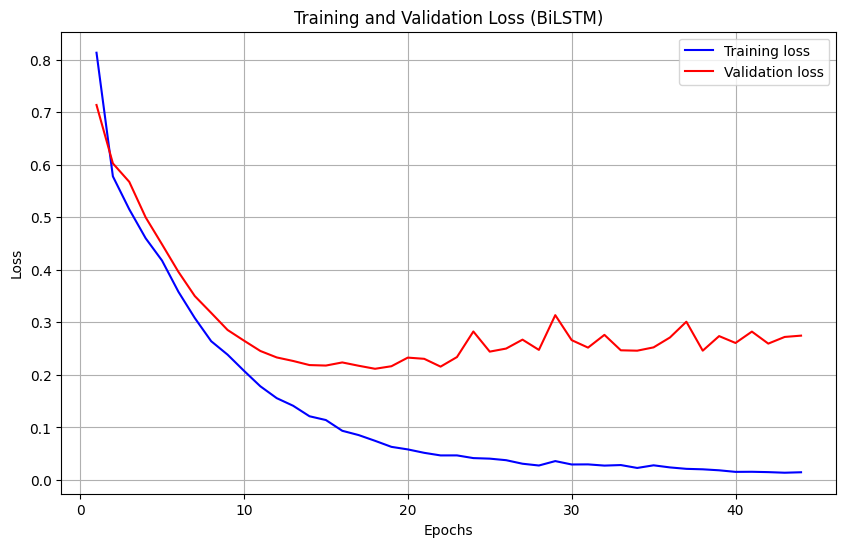

In [ ]:
history = lstm_abte_trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (BiLSTM)')

### Evaluate

In [ ]:
bilstm_abte_result = evaluate_abte_model(
    lstm_abte_trainer,
    lstm_abte_eval_dataset,
    split_name="test",
    model_name="BiLSTM ABTE"
)

Evaluation on test set using BiLSTM ABTE
Classification Report:
              precision    recall  f1-score   support

        Term       0.75      0.78      0.77      2861

   micro avg       0.75      0.78      0.77      2861
   macro avg       0.75      0.78      0.77      2861
weighted avg       0.75      0.78      0.77      2861

Accuracy: 0.9271
Precision: 0.7524
Recall: 0.7784
F1 Score: 0.7652


### Inference

In [ ]:
token_classifier = pipeline(
    task="token-classification",
    model=lstm_abte_model,
    tokenizer=lstm_tokenizer,
    aggregation_strategy="simple"
)

The model 'LSTMForTokenClassification' is not supported for token-classification. Supported models are ['PeftModelForTokenClassification', 'AlbertForTokenClassification', 'ApertusForTokenClassification', 'ArceeForTokenClassification', 'BertForTokenClassification', 'BigBirdForTokenClassification', 'BioGptForTokenClassification', 'BloomForTokenClassification', 'BrosForTokenClassification', 'CamembertForTokenClassification', 'CanineForTokenClassification', 'ConvBertForTokenClassification', 'Data2VecTextForTokenClassification', 'DebertaForTokenClassification', 'DebertaV2ForTokenClassification', 'DeepseekV3ForTokenClassification', 'DiffLlamaForTokenClassification', 'DistilBertForTokenClassification', 'ElectraForTokenClassification', 'ErnieForTokenClassification', 'EsmForTokenClassification', 'Exaone4ForTokenClassification', 'FalconForTokenClassification', 'FlaubertForTokenClassification', 'FNetForTokenClassification', 'FunnelForTokenClassification', 'GemmaForTokenClassification', 'Gemma2For

In [ ]:
test_sentence = 'The pasta tasted amazing, the staff were quite rude, and the restaurant was beautifully decorated.'
results = token_classifier(test_sentence)
results

[{'entity_group': 'Term',
  'score': np.float32(0.61542165),
  'word': 'pasta',
  'start': 4,
  'end': 9},
 {'entity_group': 'Term',
  'score': np.float32(0.9997918),
  'word': 'staff',
  'start': 30,
  'end': 35}]

### Save weight

In [ ]:
bilstm_save_path = save_model_checkpoint(
    model=lstm_abte_model,
    tokenizer=lstm_tokenizer,
    model_name="abte-bilstm"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: /content/saved_models/abte-bilstm


## MiniLM

### Tokenizer & Model definition

In [13]:
minilm_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
minilm_abte_model = AutoModelForTokenClassification.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2",
    num_labels=3,
    id2label=abte_id2label,
    label2id=abte_label2id
)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | 
------------------------+------------+-
pooler.dense.weight     | UNEXPECTED | 
embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias       | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
input_ids = torch.randint(0, 1000, (1, 10))
attention_mask = torch.ones((1, 10))
summary(
    minilm_abte_model,
    input_data=(input_ids, attention_mask),
    depth=3
)

Layer (type:depth-idx)                                  Output Shape              Param #
BertForTokenClassification                              [1, 10, 3]                --
├─BertModel: 1-1                                        [1, 10, 384]              --
│    └─BertEmbeddings: 2-1                              [1, 10, 384]              --
│    │    └─Embedding: 3-1                              [1, 10, 384]              11,720,448
│    │    └─Embedding: 3-2                              [1, 10, 384]              768
│    │    └─Embedding: 3-3                              [1, 10, 384]              196,608
│    │    └─LayerNorm: 3-4                              [1, 10, 384]              768
│    │    └─Dropout: 3-5                                [1, 10, 384]              --
│    └─BertEncoder: 2-2                                 [1, 10, 384]              --
│    │    └─ModuleList: 3-6                             --                        10,646,784
├─Dropout: 1-2                       

In [ ]:
tokenize_minilm_fn = partial(tokenize_and_align_labels, minilm_tokenizer)

minilm_abte_preprocessed_ds = ds.map(
    tokenize_minilm_fn,
    batched=True
)

Map:   0%|          | 0/3602 [00:00<?, ? examples/s]

Map:   0%|          | 0/1119 [00:00<?, ? examples/s]

In [ ]:
minilm_abte_train_dataset = minilm_abte_preprocessed_ds['train']
minilm_abte_eval_dataset = minilm_abte_preprocessed_ds['test']

### Training

In [ ]:
minilm_abte_training_args = TrainingArguments(
    output_dir='abte-restaurants-minilm',
    num_train_epochs=20,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,

    per_device_train_batch_size=256,
    per_device_eval_batch_size=256,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    seed=SEED,
)

minilm_abte_trainer = Trainer(
    model=minilm_abte_model,
    args=minilm_abte_training_args,
    train_dataset=minilm_abte_train_dataset,
    eval_dataset=minilm_abte_eval_dataset,
    data_collator=DataCollatorForTokenClassification(tokenizer=minilm_tokenizer),
    compute_metrics=compute_abte_metrics,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
train_result = minilm_abte_trainer.train()
print('Train result:', train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.808312,0.412439,0.797592,0.000000,0.000000,0.000000
2,0.280879,0.234996,0.898631,0.442702,0.671094,0.533482
3,0.153782,0.145937,0.952208,0.790003,0.850751,0.819253
4,0.084400,0.171198,0.945999,0.763105,0.793778,0.778139
5,0.059754,0.140606,0.955972,0.824708,0.863334,0.843579
6,0.040120,0.143205,0.958135,0.851737,0.865432,0.858530
7,0.028460,0.156890,0.956160,0.848443,0.866830,0.857538
8,0.026635,0.169376,0.956865,0.861393,0.860189,0.860790
9,0.018498,0.154051,0.960111,0.853265,0.867878,0.860509
10,0.017264,0.176516,0.957900,0.856794,0.857393,0.857093


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Train result: TrainOutput(global_step=300, training_loss=0.08178311208883922, metrics={'train_runtime': 254.8067, 'train_samples_per_second': 282.724, 'train_steps_per_second': 1.177, 'total_flos': 416329771510008.0, 'train_loss': 0.08178311208883922, 'epoch': 20.0})


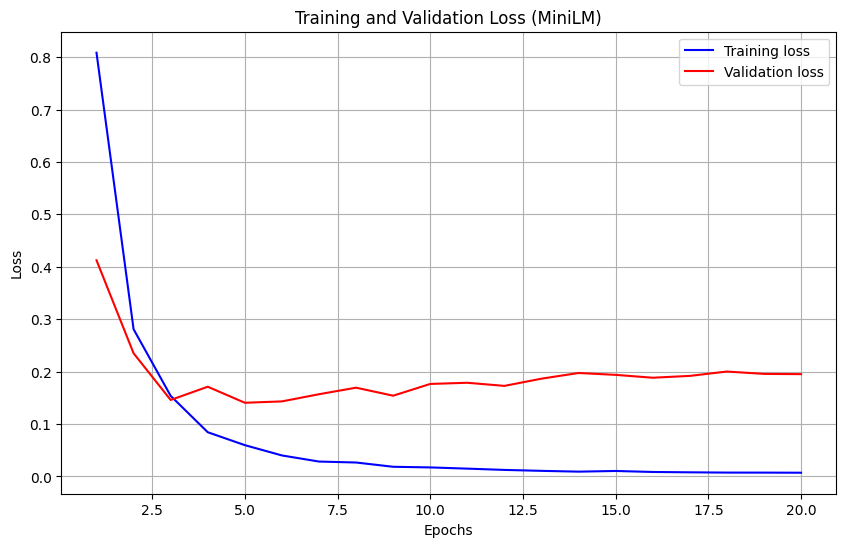

In [ ]:
history = minilm_abte_trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (MiniLM)')

### Evaluate

In [ ]:
minilm_abte_result = evaluate_abte_model(
    minilm_abte_trainer,
    minilm_abte_eval_dataset,
    split_name="test",
    model_name="MiniLM ABTE"
)

Evaluation on test set using MiniLM ABTE
Classification Report:
              precision    recall  f1-score   support

        Term       0.86      0.87      0.87      2861

   micro avg       0.86      0.87      0.87      2861
   macro avg       0.86      0.87      0.87      2861
weighted avg       0.86      0.87      0.87      2861

Accuracy: 0.9595
Precision: 0.8629
Recall: 0.8714
F1 Score: 0.8671


### Inference

In [ ]:
token_classifier = pipeline(
    task="token-classification",
    model=minilm_abte_model,
    tokenizer=minilm_tokenizer,
    aggregation_strategy="simple"
)

In [ ]:
test_sentence = 'The pasta tasted amazing, the staff were quite rude, and the restaurant was beautifully decorated.'
results = token_classifier(test_sentence)
results

[{'entity_group': 'Term',
  'score': np.float32(0.99765825),
  'word': 'pasta',
  'start': 4,
  'end': 9},
 {'entity_group': 'Term',
  'score': np.float32(0.99778974),
  'word': 'staff',
  'start': 30,
  'end': 35}]

### Save weight

In [ ]:
minilm_save_path = save_model_checkpoint(
    model=minilm_abte_model,
    tokenizer=minilm_tokenizer,
    model_name="abte-minilm"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: /content/saved_models/abte-minilm


# STAGE 2: ABSC

## Build ABSC dataset

In [14]:
def build_absc_examples(examples):
    sentences = []
    aspects = []
    labels = []

    for tokens, tags, pols in zip(
        examples["Tokens"],
        examples["Tags"],
        examples["Polarities"]
    ):
        current_aspect = []
        current_pols = []

        for token, tag, pol in zip(tokens, tags, pols):
            tag = int(tag)
            pol = int(pol)

            if tag == 1:
                if current_aspect:
                    valid_pols = [p for p in current_pols if p != -1]

                    if valid_pols:
                        sentences.append(" ".join(tokens))
                        aspects.append(" ".join(current_aspect))
                        labels.append(valid_pols[0])

                current_aspect = [token]
                current_pols = [pol]

            elif tag == 2 and current_aspect:
                current_aspect.append(token)
                current_pols.append(pol)

            else:
                if current_aspect:
                    valid_pols = [p for p in current_pols if p != -1]

                    if valid_pols:
                        sentences.append(" ".join(tokens))
                        aspects.append(" ".join(current_aspect))
                        labels.append(valid_pols[0])

                current_aspect = []
                current_pols = []

        if current_aspect:
            valid_pols = [p for p in current_pols if p != -1]

            if valid_pols:
                sentences.append(" ".join(tokens))
                aspects.append(" ".join(current_aspect))
                labels.append(valid_pols[0])

    return {
        "sentence": sentences,
        "aspect": aspects,
        "labels": labels
    }

absc_ds = ds.map(
    build_absc_examples,
    batched=True,
    remove_columns=ds["train"].column_names
)

Map:   0%|          | 0/3602 [00:00<?, ? examples/s]

Map:   0%|          | 0/1119 [00:00<?, ? examples/s]

In [15]:
print(f"Number of ABSC examples: {len(absc_ds['train'])}")

Number of ABSC examples: 3602


/tmp/ipykernel_5796/220080476.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels_str, y=counts, palette=colors)


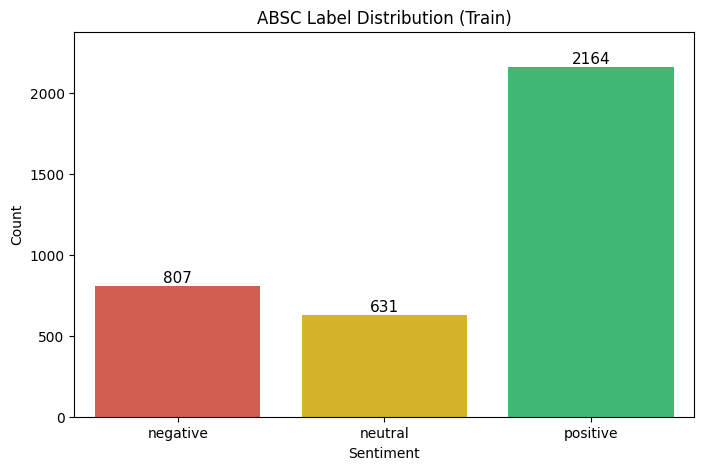

In [16]:
labels = np.array(absc_ds["train"]["labels"])
labels = labels[labels != -1]

unique, counts = np.unique(labels, return_counts=True)
label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

labels_str = [label_map[int(l)] for l in unique]
palette = {
    "negative": "#e74c3c",
    "neutral": "#f1c40f",
    "positive": "#2ecc71"
}

colors = [palette[l] for l in labels_str]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels_str, y=counts, palette=colors)

plt.title("ABSC Label Distribution (Train)")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, str(v), ha='center', fontsize=11)

plt.ylim(0, max(counts)*1.1)
plt.show()

## LSTM (Baseline Model)

### Model definition

In [ ]:
class LSTMSequenceClassifierConfig(PretrainedConfig):
    model_type = "lstm-sequence-classifier"

    def __init__(
        self,
        vocab_size=5000,
        embedding_dim=128,
        hidden_dim=256,
        num_labels=3,
        num_layers=2,
        dropout=0.3,
        bidirectional=True,
        id2label=None,
        label2id=None,
        **kwargs
    ):
        super().__init__(
            id2label=id2label,
            label2id=label2id,
            **kwargs
        )

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_labels = num_labels
        self.num_layers = num_layers
        self.dropout = dropout
        self.bidirectional = bidirectional

In [ ]:
class LSTMForSequenceClassification(PreTrainedModel):
    config_class = LSTMSequenceClassifierConfig

    def __init__(self, config):
        super().__init__(config)

        self.embedding = nn.Embedding(
            config.vocab_size,
            config.embedding_dim
        )

        rnn_dropout = config.dropout if config.num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=config.embedding_dim,
            hidden_size=config.hidden_dim,
            num_layers=config.num_layers,
            batch_first=True,
            dropout=rnn_dropout,
            bidirectional=config.bidirectional
        )

        lstm_output_dim = config.hidden_dim * 2 if config.bidirectional else config.hidden_dim

        self.dropout = nn.Dropout(config.dropout)
        self.classifier = nn.Linear(lstm_output_dim, config.num_labels)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        outputs, _ = self.lstm(x)

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (outputs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-8)
        else:
            pooled = outputs.mean(dim=1)

        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits
        )

In [ ]:
absc_lstm_config = LSTMSequenceClassifierConfig(
    vocab_size=lstm_tokenizer.vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_labels=3,
    num_layers=2,
    dropout=0.3,
    bidirectional=True,
    id2label=absc_id2label,
    label2id=absc_label2id
)

lstm_absc_model = LSTMForSequenceClassification(absc_lstm_config)

In [ ]:
summary(lstm_absc_model, input_size=(1, 10), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
LSTMForSequenceClassification            [1, 3]                    --
├─Embedding: 1-1                         [1, 10, 128]              548,608
├─Dropout: 1-2                           [1, 10, 128]              --
├─LSTM: 1-3                              [1, 10, 512]              2,367,488
├─Dropout: 1-4                           [1, 512]                  --
├─Linear: 1-5                            [1, 3]                    1,539
Total params: 2,917,635
Trainable params: 2,917,635
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 24.23
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 11.67
Estimated Total Size (MB): 11.72

### Training

In [ ]:
tokenize_lstm_fn = partial(tokenize_absc_examples, lstm_tokenizer)

lstm_absc_preprocessed_ds = absc_ds.map(
    tokenize_lstm_fn,
    batched=True
)
lstm_absc_train_dataset = lstm_absc_preprocessed_ds['train']
lstm_absc_eval_dataset = lstm_absc_preprocessed_ds['test']

Map:   0%|          | 0/3602 [00:00<?, ? examples/s]

Map:   0%|          | 0/1119 [00:00<?, ? examples/s]

In [ ]:
lstm_absc_training_args = TrainingArguments(
    output_dir='absc-restaurants-lstm',
    num_train_epochs=100,
    learning_rate=5e-4,
    per_device_train_batch_size=512,
    per_device_eval_batch_size=512,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    seed=SEED,
)

lstm_absc_trainer = Trainer(
    model=lstm_absc_model,
    args=lstm_absc_training_args,
    train_dataset=lstm_absc_train_dataset,
    eval_dataset=lstm_absc_eval_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=lstm_tokenizer),
    compute_metrics=compute_absc_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

In [ ]:
train_result = lstm_absc_trainer.train()
print("Train result:", train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.983806,0.942201,0.649687,0.216562,0.333333,0.262550
2,0.953382,0.894850,0.649687,0.216562,0.333333,0.262550
3,0.947313,0.868092,0.649687,0.216562,0.333333,0.262550
4,0.943383,0.849753,0.649687,0.216562,0.333333,0.262550
5,0.892306,0.837070,0.649687,0.216562,0.333333,0.262550
6,0.880620,0.822100,0.653262,0.439952,0.340136,0.276607
7,0.842988,0.805229,0.664879,0.714626,0.378393,0.345285
8,0.834144,0.784534,0.656836,0.588202,0.405321,0.387089
9,0.794222,0.774747,0.665773,0.633373,0.414875,0.403887
10,0.765391,0.797023,0.675603,0.627288,0.437309,0.430413


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Train result: TrainOutput(global_step=296, training_loss=0.6149118031198914, metrics={'train_runtime': 103.7194, 'train_samples_per_second': 3472.831, 'train_steps_per_second': 7.713, 'total_flos': 165736588781844.0, 'train_loss': 0.6149118031198914, 'epoch': 37.0})


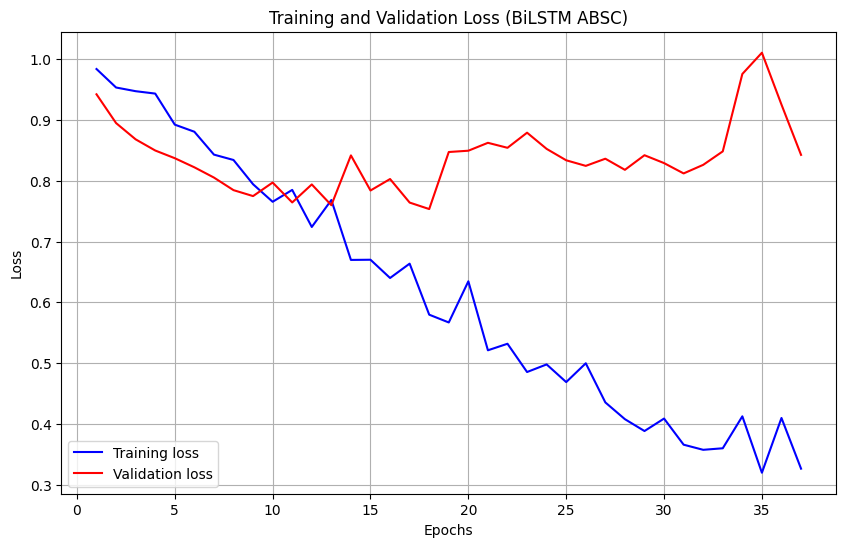

In [ ]:
history = lstm_absc_trainer.state.log_history
plot_loss_curves(history, title="Training and Validation Loss (BiLSTM ABSC)")

### Evaluate

In [ ]:
lstm_absc_result = evaluate_absc_model(
    lstm_absc_trainer,
    lstm_absc_eval_dataset,
    split_name="test",
    model_name="BiLSTM ABSC"
)

Evaluation on test set using BiLSTM ABSC
Classification Report:
              precision    recall  f1-score   support

    negative       0.56      0.45      0.50       196
     neutral       0.34      0.57      0.43       196
    positive       0.84      0.74      0.79       727

    accuracy                           0.66      1119
   macro avg       0.58      0.59      0.57      1119
weighted avg       0.71      0.66      0.67      1119

Accuracy: 0.6577
Precision: 0.5816
Recall: 0.5871
F1 Score: 0.5720


### Inference

In [ ]:
predict_absa(
    sentence=test_sentence,
    term="pasta",
    absc_model=lstm_absc_model,
    absc_tokenizer=lstm_tokenizer,
    device=device
)

{'sentence': 'The pasta tasted amazing, the staff were quite rude, and the restaurant was beautifully decorated.',
 'results': [{'term': 'restaurant',
   'term_score': None,
   'sentiment_id': 0,
   'sentiment': 'negative',
   'sentiment_score': 0.8083896636962891,
   'entity': None,
   'start': None,
   'end': None}]}

In [ ]:
predict_absa(
    sentence=test_sentence,
    term=None,
    abte_model=minilm_abte_model,
    abte_tokenizer=minilm_tokenizer,
    absc_model=lstm_absc_model,
    absc_tokenizer=lstm_tokenizer,
    device=device
)

{'sentence': 'The pasta tasted amazing, the staff were quite rude, and the restaurant was beautifully decorated.',
 'results': [{'term': 'pasta',
   'term_score': 0.9976582527160645,
   'sentiment_id': 0,
   'sentiment': 'negative',
   'sentiment_score': 0.7931331992149353,
   'entity': 'Term',
   'start': 4,
   'end': 9},
  {'term': 'staff',
   'term_score': 0.997789740562439,
   'sentiment_id': 0,
   'sentiment': 'negative',
   'sentiment_score': 0.6329895257949829,
   'entity': 'Term',
   'start': 30,
   'end': 35}]}

### Save weight

In [ ]:
lstm_absc_save_path = save_model_checkpoint(
    model=lstm_absc_model,
    tokenizer=lstm_tokenizer,
    model_name="absc-bilstm"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: /content/saved_models/absc-bilstm


## MiniLM

### Model definition

In [17]:
minilm_absc_model = AutoModelForSequenceClassification.from_pretrained(
    "sentence-transformers/all-MiniLM-L12-v2",
    num_labels=3,
    id2label=absc_id2label,
    label2id=absc_label2id
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
input_ids = torch.randint(0, 1000, (1, 10))
attention_mask = torch.ones((1, 10))
summary(
    minilm_abte_model,
    input_data=(input_ids, attention_mask),
    depth=3
)

Layer (type:depth-idx)                                  Output Shape              Param #
BertForTokenClassification                              [1, 10, 3]                --
├─BertModel: 1-1                                        [1, 10, 384]              --
│    └─BertEmbeddings: 2-1                              [1, 10, 384]              --
│    │    └─Embedding: 3-1                              [1, 10, 384]              11,720,448
│    │    └─Embedding: 3-2                              [1, 10, 384]              768
│    │    └─Embedding: 3-3                              [1, 10, 384]              196,608
│    │    └─LayerNorm: 3-4                              [1, 10, 384]              768
│    │    └─Dropout: 3-5                                [1, 10, 384]              --
│    └─BertEncoder: 2-2                                 [1, 10, 384]              --
│    │    └─ModuleList: 3-6                             --                        10,646,784
├─Dropout: 1-2                       

In [19]:
tokenize_minilm_fn = partial(tokenize_absc_examples, minilm_tokenizer)

minilm_absc_preprocessed_ds = absc_ds.map(
    tokenize_minilm_fn,
    batched=True
)

Map:   0%|          | 0/3602 [00:00<?, ? examples/s]

Map:   0%|          | 0/1119 [00:00<?, ? examples/s]

In [20]:
minilm_absc_train_dataset = minilm_absc_preprocessed_ds['train']
minilm_absc_eval_dataset = minilm_absc_preprocessed_ds['test']

### Training

In [21]:
minilm_absc_training_args = TrainingArguments(
    output_dir='absc-restaurants-minilm',
    num_train_epochs=20,
    learning_rate=3e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,

    per_device_train_batch_size=256,
    per_device_eval_batch_size=256,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    seed=SEED,
)

minilm_absc_trainer = Trainer(
    model=minilm_absc_model,
    args=minilm_absc_training_args,
    train_dataset=minilm_absc_train_dataset,
    eval_dataset=minilm_absc_eval_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=minilm_tokenizer),
    compute_metrics=compute_absc_metrics,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [22]:
train_result = minilm_absc_trainer.train()
print('Train result:', train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.000686,0.866367,0.649687,0.216562,0.333333,0.262550
2,0.795030,0.814576,0.596068,0.414478,0.546805,0.415569
3,0.711400,0.591545,0.780161,0.749972,0.673554,0.645086
4,0.580928,0.564109,0.798928,0.743564,0.675729,0.682717
5,0.440055,0.564688,0.806971,0.764688,0.672403,0.681725
6,0.381662,0.540655,0.806971,0.731751,0.689793,0.707538
7,0.308354,0.577645,0.808758,0.759088,0.685741,0.692703
8,0.252403,0.592204,0.827525,0.776865,0.720214,0.743831
9,0.192074,0.539823,0.848079,0.794345,0.756845,0.771562
10,0.130479,0.657299,0.827525,0.772038,0.715245,0.735539


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Train result: TrainOutput(global_step=300, training_loss=0.265615587135156, metrics={'train_runtime': 512.3404, 'train_samples_per_second': 140.61, 'train_steps_per_second': 0.586, 'total_flos': 874432448449560.0, 'train_loss': 0.265615587135156, 'epoch': 20.0})


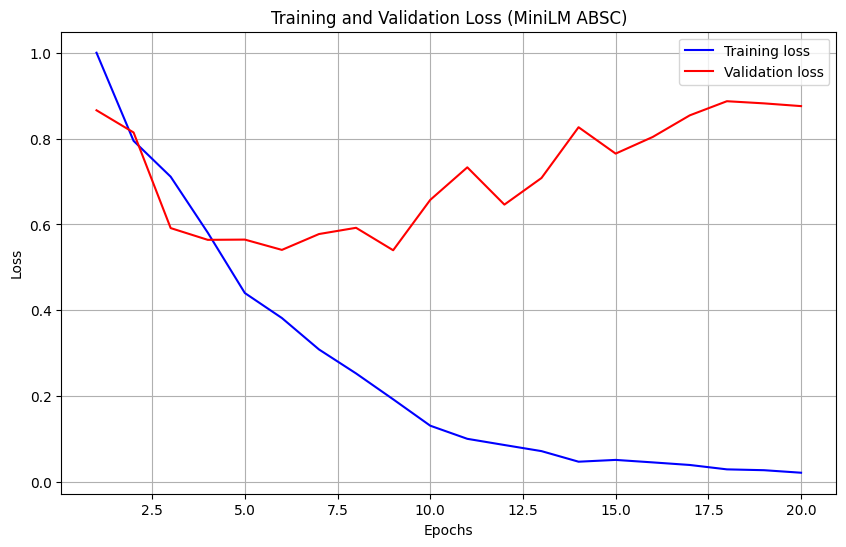

In [23]:
history = minilm_absc_trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (MiniLM ABSC)')

### Evaluate

In [24]:
minilm_absc_result = evaluate_absc_model(
    minilm_absc_trainer,
    minilm_absc_eval_dataset,
    split_name="test",
    model_name="MiniLM ABSC"
)

Evaluation on test set using MiniLM ABSC
Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.77      0.77       196
     neutral       0.73      0.56      0.63       196
    positive       0.89      0.95      0.92       727

    accuracy                           0.85      1119
   macro avg       0.80      0.76      0.77      1119
weighted avg       0.84      0.85      0.84      1119

Accuracy: 0.8490
Precision: 0.7966
Recall: 0.7585
F1 Score: 0.7735


### Inference

In [ ]:
predict_absa(
    sentence=test_sentence,
    term="pasta",
    absc_model=minilm_absc_model,
    absc_tokenizer=minilm_tokenizer,
    device=device
)

{'sentence': 'The pasta tasted amazing, the staff were quite rude, and the restaurant was beautifully decorated.',
 'results': [{'term': 'pasta',
   'term_score': None,
   'sentiment_id': 2,
   'sentiment': 'positive',
   'sentiment_score': 0.9926181435585022,
   'entity': None,
   'start': None,
   'end': None}]}

In [ ]:
predict_absa(
    sentence=test_sentence,
    term=None,
    abte_model=minilm_abte_model,
    abte_tokenizer=minilm_tokenizer,
    absc_model=minilm_absc_model,
    absc_tokenizer=minilm_tokenizer,
    device=device
)

{'sentence': 'The pasta tasted amazing, the staff were quite rude, and the restaurant was beautifully decorated.',
 'results': [{'term': 'pasta',
   'term_score': 0.9976582527160645,
   'sentiment_id': 2,
   'sentiment': 'positive',
   'sentiment_score': 0.9926181435585022,
   'entity': 'Term',
   'start': 4,
   'end': 9},
  {'term': 'staff',
   'term_score': 0.997789740562439,
   'sentiment_id': 2,
   'sentiment': 'positive',
   'sentiment_score': 0.6509749889373779,
   'entity': 'Term',
   'start': 30,
   'end': 35}]}

### Save weight

In [25]:
minilm_absc_save_path = save_model_checkpoint(
    model=minilm_absc_model,
    tokenizer=minilm_tokenizer,
    model_name="absc-minilm"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: /content/saved_models/absc-minilm


In [30]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

source_path = "./saved_models/absc-minilm"
destination_path = "/content/drive/MyDrive/ABSA-restaurant/saved_models/absc-minilm"

# Create the parent directory in Google Drive if it doesn't exist
os.makedirs(os.path.dirname(destination_path), exist_ok=True)

# Check if the source directory exists before copying
if os.path.exists(source_path):
    # If the destination directory already exists, remove it first to avoid errors
    if os.path.exists(destination_path):
        shutil.rmtree(destination_path)
    shutil.copytree(source_path, destination_path)
    print(f"Successfully copied '{source_path}' to '{destination_path}'")
else:
    print(f"Source directory '{source_path}' does not exist.")

Mounted at /content/drive
Successfully copied './saved_models/absc-minilm' to '/content/drive/MyDrive/ABSA-restaurant/saved_models/absc-minilm'
